In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [192]:
# basic preprocessing - removing irrelevant columns
gdp = pd.read_excel('NY_GDP_PCAP (3).xlsx')
infant = pd.read_excel('SH_DYN_IMRT (1).xlsx')
maternal = pd.read_excel('SH_STA_MORT.xlsx')
maternal = maternal.drop(columns=['Goal', 'Target', 'Indicator', 'SeriesCode', 'SeriesDescription', 'GeoAreaCode', 'Age', 'Freq', 'Location', 'Reporting Type', 'Sex', 'Units'])
gdp = gdp.drop(columns=['Goal', 'Target', 'Indicator', 'SeriesCode', 'SeriesDescription', 'GeoAreaCode', 'Observation Status', 'Reporting Type', 'Units'])
infant = infant.drop(columns=['Goal', 'Target', 'Indicator', 'SeriesCode', 'SeriesDescription', 'GeoAreaCode', 'Reporting Type', 'Units'])

# filter infant to double sex

infant = infant[infant['Sex'] == 'BOTHSEX']

# gdp: Annual growth rate of real GDP per capita (%)
# maternal: Maternal mortality ratio (modeled estimate, per 100,000 live births)
# infant: measures Infant mortality rate (deaths per 1,000 live births), units is per 1000 live births

Calculate Correlation between Maternal and GDP

In [75]:
# Convert datasets from wide to long

years_now = ['2000', '2001', '2002', '2003', '2004', '2005', '2006',
       '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
       '2016', '2017', '2018', '2019', '2020']
maternal_long = pd.melt(maternal, id_vars=['GeoAreaName'], 
                  value_vars=years_now,
                  var_name='Year', 
                  value_name='Maternal Mortality Ratio per 100,000 Live Births')
countries_mat = list(maternal_long['GeoAreaName'].unique())
gdp = gdp[gdp['GeoAreaName'].isin(countries_mat)]
maternal_long = maternal_long[maternal_long['GeoAreaName'].isin(list(gdp['GeoAreaName'].unique()))]
gdp_long = pd.melt(gdp, id_vars=['GeoAreaName'],
                   value_vars=years_now,
                   var_name='Year',
                   value_name='Average GDP Growth per Capita (%)')

In [116]:
maternal_to_gdp = pd.merge(maternal_long, gdp_long, on=['GeoAreaName', 'Year'], how='left')

In [109]:
maternal_to_gdp.isna().sum()

GeoAreaName                                           0
Year                                                  0
Maternal Mortality Ratio per 100,000 Live Births      0
Average GDP Growth per Capita (%)                   378
dtype: int64

In [121]:
maternal_to_gdp = maternal_to_gdp.rename(columns={'Maternal Mortality Ratio per 100,000 Live Births': 'mortality_rate', 'Average GDP Growth per Capita (%)': 'gdp_growth'})

In [144]:
def country_corr(group):
    return group['mortality_rate'].corr(group['gdp_growth'], method='spearman')

country_correlations = maternal_to_gdp.groupby('GeoAreaName').apply(country_corr)

correlation_df_s = country_correlations.reset_index()
correlation_df_s.columns = ['GeoAreaName', 'mortality_gdp_corr']


/var/folders/sm/h_vm8nzd6z54q1s5kfsmm6x00000gn/T/ipykernel_23172/479536921.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  country_correlations = maternal_to_gdp.groupby('GeoAreaName').apply(country_corr)


In [146]:
correlation_df_s

,GeoAreaName,mortality_gdp_corr
0,Afghanistan,0.040286
1,Africa,0.657991
2,Albania,0.740500
3,Algeria,0.481458
4,Americas,0.050344
...,...,...
217,Western Europe,0.127161
218,World,0.180339
219,Yemen,0.602793
220,Zambia,0.556386


In [125]:
def safe_cross_corr(x, y, max_lag=5):
    x = np.array(x)
    y = np.array(y)
    corrs = []
    for lag in range(max_lag + 1):
        if len(x) > lag and len(y) > lag:
            corr = np.corrcoef(x[:-lag or None], y[lag:])[0, 1]
            corrs.append(corr)
        else:
            corrs.append(np.nan)
    return corrs

# Applying cross-correlation
cross_corr_df = maternal_to_gdp.groupby('GeoAreaName').apply(lambda group: safe_cross_corr(group['mortality_rate'], group['gdp_growth'], max_lag=5))

/var/folders/sm/h_vm8nzd6z54q1s5kfsmm6x00000gn/T/ipykernel_23172/4143387539.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cross_corr_df = maternal_to_gdp.groupby('GeoAreaName').apply(lambda group: safe_cross_corr(group['mortality_rate'], group['gdp_growth'], max_lag=5))


In [137]:
cross_corr_df

GeoAreaName
Afghanistan       [0.27925903743207886, 0.3265805369275381, 0.48...
Africa            [0.5620668928218179, 0.6101129196964856, 0.678...
Albania           [0.6645132995989192, 0.7977045229308889, 0.725...
Algeria           [0.5731007002621259, 0.53176770123541, 0.62899...
Americas          [-0.15247524441225682, 0.008091046821718156, 0...
                                        ...                        
Western Europe    [0.16751005330592814, 0.1789461559242632, 0.25...
World             [0.2151648480726934, 0.15936660472887745, 0.26...
Yemen             [0.42180575778252943, 0.48450136417797324, 0.5...
Zambia            [0.5809377747660887, 0.698549929348279, 0.6855...
Zimbabwe          [0.4164295177108513, 0.5266308657733053, 0.592...
Length: 222, dtype: object

In [147]:
maternal_to_gdp

,GeoAreaName,Year,mortality_rate,gdp_growth
0,Afghanistan,2000,1346.14410,-6.6
1,Africa,2000,727.92170,1.3
2,Albania,2000,14.32641,7.7
3,Algeria,2000,159.17568,2.4
4,Americas,2000,68.38973,2.7
...,...,...,...,...
4657,Western Europe,2020,5.92971,-5.3
4658,World,2020,223.47466,-3.8
4659,Yemen,2020,183.39972,-1.7
4660,Zambia,2020,134.66542,-5.6


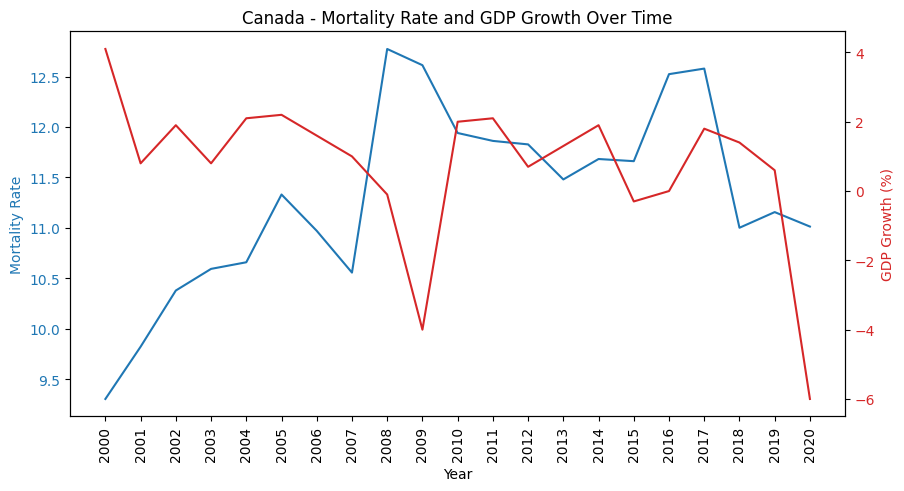

In [250]:
country = 'Canada'
df_country = maternal_to_gdp[maternal_to_gdp['GeoAreaName'] == country]

# Sort by year to ensure correct order
df_country = df_country.sort_values('Year')

# Plotting
fig, ax1 = plt.subplots(figsize=(10, 5))

color1 = 'tab:blue'
ax1.set_xlabel('Year')
plt.xticks(rotation=90)
ax1.set_ylabel('Mortality Rate', color=color1)
ax1.plot(df_country['Year'], df_country['mortality_rate'], color=color1, label='Mortality Rate')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()  # instantiate a second y-axis that shares the same x-axis

color2 = 'tab:red'
ax2.set_ylabel('GDP Growth (%)', color=color2)
ax2.plot(df_country['Year'], df_country['gdp_growth'], color=color2, label='GDP Growth (%)')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title(f"{country} - Mortality Rate and GDP Growth Over Time")
plt.show()


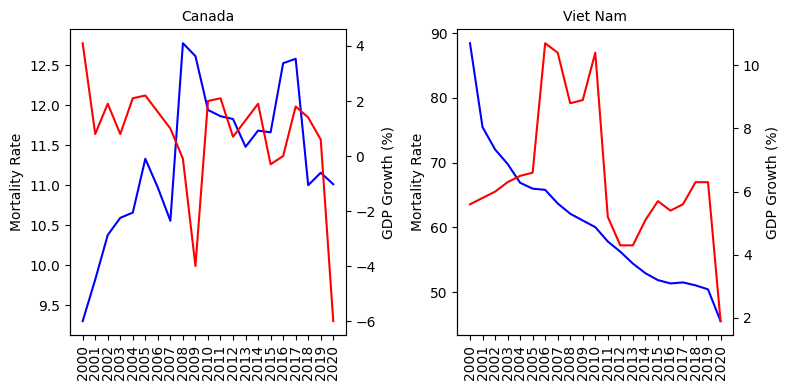

In [251]:
countries = ['Canada', 'Viet Nam']
df_subset = maternal_to_gdp[maternal_to_gdp['GeoAreaName'].isin(countries)]

# Set up the figure
g = sns.FacetGrid(df_subset, col="GeoAreaName", col_wrap=2, height=4, sharey=False)

# Plot both mortality and GDP growth
def plot_both(data, color):
    ax = plt.gca()
    ax.plot(data['Year'], data['mortality_rate'], label='Mortality Rate', color='blue')
    ax2 = ax.twinx()
    ax2.plot(data['Year'], data['gdp_growth'], label='GDP Growth', color='red')
    ax.set_ylabel("Mortality Rate")
    ax2.set_ylabel("GDP Growth (%)")
    ax.set_xticks(data['Year'])  # ensure correct ticks
    ax.set_xticklabels(data['Year'], rotation=90)

g.map_dataframe(plot_both)
g.set_titles(col_template="{col_name}")
plt.tight_layout()
plt.show()

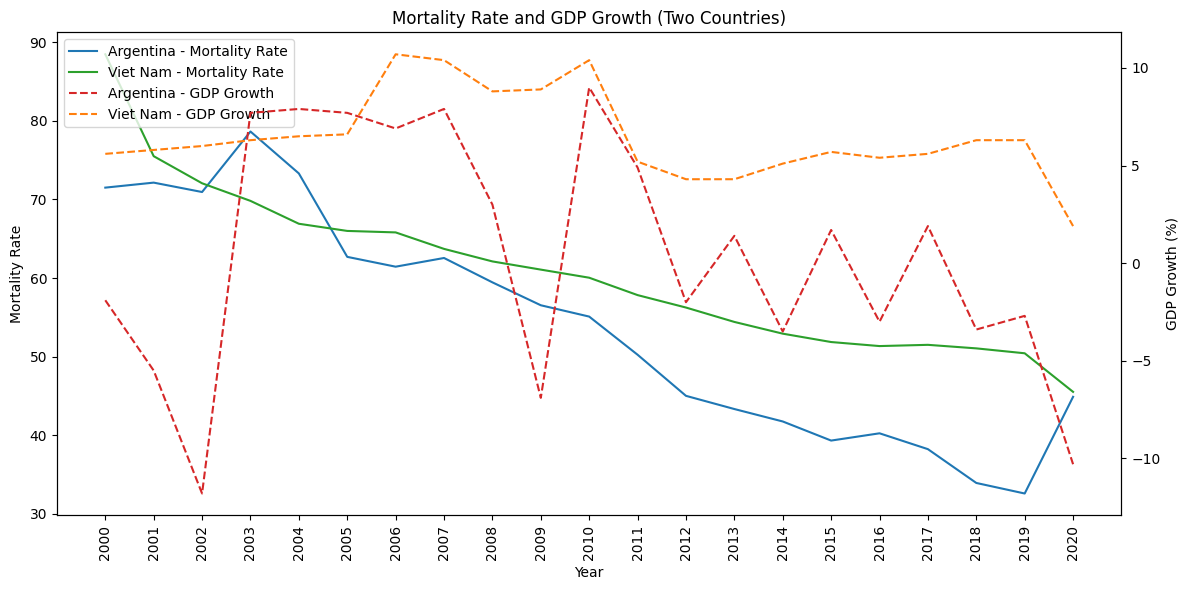

In [253]:
# Filter for two countries
countries = ['Argentina', 'Viet Nam']
df_subset = maternal_to_gdp[maternal_to_gdp['GeoAreaName'].isin(countries)].sort_values('Year')

# Create the figure and axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary axis for mortality_rate
colors = ['tab:blue', 'tab:green']
for i, country in enumerate(countries):
    df_c = df_subset[df_subset['GeoAreaName'] == country]
    ax1.plot(df_c['Year'], df_c['mortality_rate'], label=f'{country} - Mortality Rate', color=colors[i], linestyle='-')

ax1.set_xlabel('Year')
ax1.set_ylabel('Mortality Rate')
ax1.tick_params(axis='y')
ax1.set_xticks(df_c['Year'])
ax1.set_xticklabels(df_c['Year'], rotation=90, fontsize=10)

# Twin y-axis for GDP growth
ax2 = ax1.twinx()
colors_gdp = ['tab:red', 'tab:orange']
for i, country in enumerate(countries):
    df_c = df_subset[df_subset['GeoAreaName'] == country]
    ax2.plot(df_c['Year'], df_c['gdp_growth'], label=f'{country} - GDP Growth', color=colors_gdp[i], linestyle='--')

ax2.set_ylabel('GDP Growth (%)')
ax2.tick_params(axis='y')

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title('Mortality Rate and GDP Growth (Two Countries)')
plt.tight_layout()
plt.show()

In [187]:
cross_corr_df

GeoAreaName
Afghanistan       [0.27925903743207886, 0.3265805369275381, 0.48...
Africa            [0.5620668928218179, 0.6101129196964856, 0.678...
Albania           [0.6645132995989192, 0.7977045229308889, 0.725...
Algeria           [0.5731007002621259, 0.53176770123541, 0.62899...
Americas          [-0.15247524441225682, 0.008091046821718156, 0...
                                        ...                        
Western Europe    [0.16751005330592814, 0.1789461559242632, 0.25...
World             [0.2151648480726934, 0.15936660472887745, 0.26...
Yemen             [0.42180575778252943, 0.48450136417797324, 0.5...
Zambia            [0.5809377747660887, 0.698549929348279, 0.6855...
Zimbabwe          [0.4164295177108513, 0.5266308657733053, 0.592...
Length: 222, dtype: object

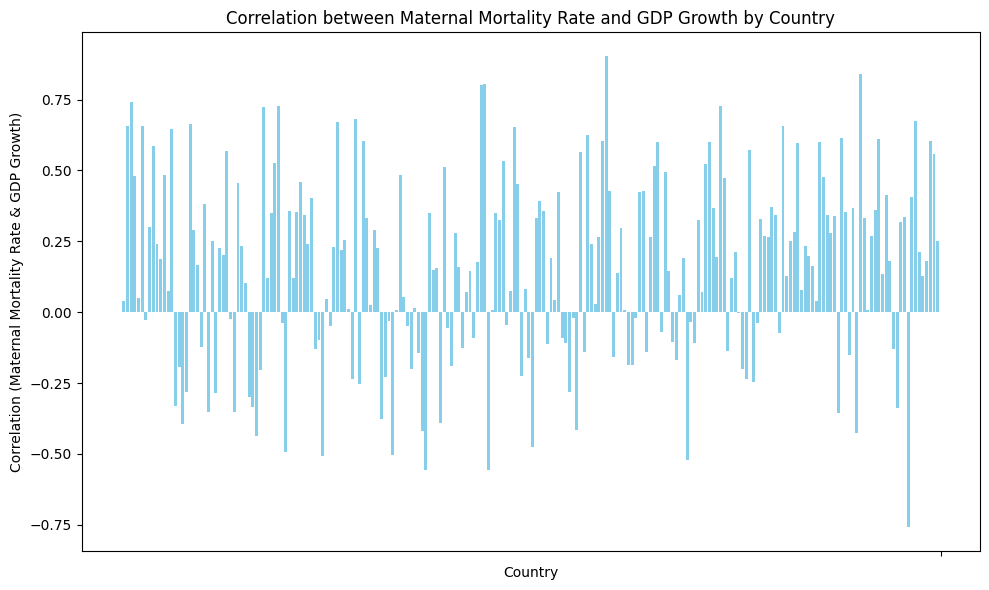

In [223]:
plt.figure(figsize=(10, 6))
plt.bar(correlation_df_s['GeoAreaName'], correlation_df_s['mortality_gdp_corr'], color='skyblue')

# Add labels and title
plt.xlabel('Country')
plt.ylabel('Correlation (Maternal Mortality Rate & GDP Growth)')
plt.title('Correlation between Maternal Mortality Rate and GDP Growth by Country')
plt.xticks('')

# Rotate x-axis labels for readability
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [191]:
correlation_df_s['mortality_gdp_corr'].mean()

0.1574832158467021

Now, let's look at infant correlation

In [202]:
# Convert datasets from wide to long

infant_long = pd.melt(infant, id_vars=['GeoAreaName'], 
                  value_vars=years_now,
                  var_name='Year', 
                  value_name='infant_mortality')
countries_infant = list(infant_long['GeoAreaName'].unique())
gdp_infant_long = gdp[gdp['GeoAreaName'].isin(countries_infant)]
infant_long = infant_long[infant_long['GeoAreaName'].isin(list(gdp_infant_long['GeoAreaName'].unique()))]
gdp_infant_long = pd.melt(gdp, id_vars=['GeoAreaName'],
                   value_vars=years_now,
                   var_name='Year',
                   value_name='gdp_growth')

In [211]:
infant_to_gdp = pd.merge(infant_long, gdp_infant_long, on=['GeoAreaName', 'Year'], how='left')

In [219]:
def country_corr(group):
    return group['infant_mortality'].corr(group['gdp_growth'], method='spearman')

infant_correlations = infant_to_gdp.groupby('GeoAreaName').apply(country_corr)

correlation_df_i = infant_correlations.reset_index()
correlation_df_i.columns = ['GeoAreaName', 'infant_morality_gdp_corr']

/var/folders/sm/h_vm8nzd6z54q1s5kfsmm6x00000gn/T/ipykernel_23172/2385349672.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  infant_correlations = infant_to_gdp.groupby('GeoAreaName').apply(country_corr)


In [221]:
correlation_df_i['infant_morality_gdp_corr'].mean()

0.21239585921408502

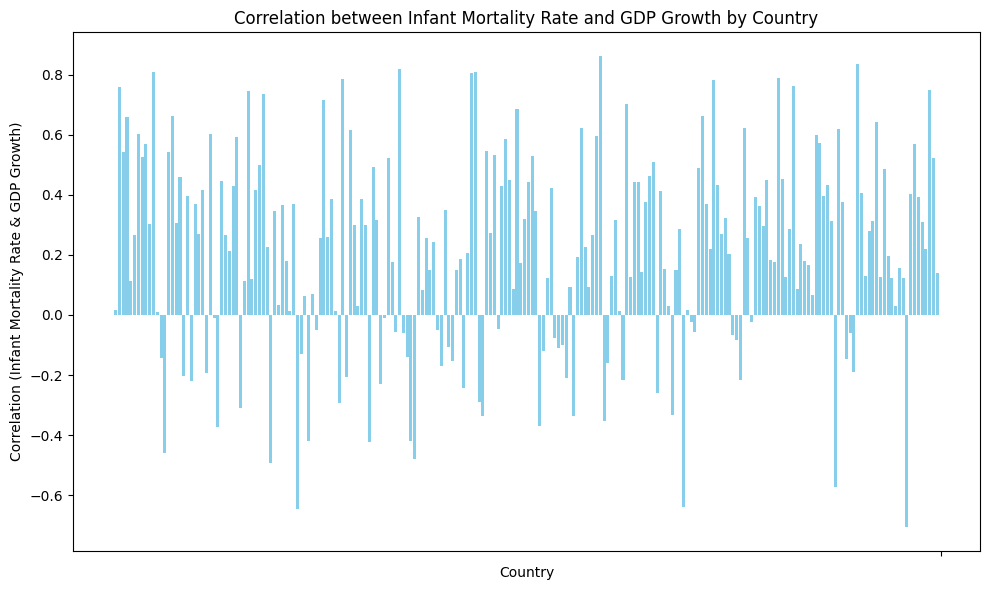

In [222]:
plt.figure(figsize=(10, 6))
plt.bar(correlation_df_i['GeoAreaName'], correlation_df_i['infant_morality_gdp_corr'], color='skyblue')

# Add labels and title
plt.xlabel('Country')
plt.ylabel('Correlation (Infant Mortality Rate & GDP Growth)')
plt.title('Correlation between Infant Mortality Rate and GDP Growth by Country')
plt.xticks('')

# Rotate x-axis labels for readability
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [224]:
from statsmodels.tsa.stattools import coint

In [225]:
country = 'Philippines'
df_country = maternal_to_gdp[maternal_to_gdp['GeoAreaName'] == country].sort_values('Year')
maternal = df_country['mortality_rate']
gdp = df_country['gdp_growth']
coint_stat, p_value, crit_values = coint(maternal, gdp)

print("Cointegration test statistic:", coint_stat)
print("p-value:", p_value)
print("Critical values:", crit_values)

Cointegration test statistic: -0.528732451336115
p-value: 0.9622220493849326
Critical values: [-4.5278525 -3.6586925 -3.26331  ]


In [226]:
country = 'Philippines'
df_country = infant_to_gdp[infant_to_gdp['GeoAreaName'] == country].sort_values('Year')
infant = df_country['infant_mortality']
gdp = df_country['gdp_growth']
coint_stat, p_value, crit_values = coint(infant, gdp)

print("Cointegration test statistic:", coint_stat)
print("p-value:", p_value)
print("Critical values:", crit_values)

Cointegration test statistic: -1.9521197687573797
p-value: 0.553359215798194
Critical values: [-4.5278525 -3.6586925 -3.26331  ]


In [227]:
results = []

for country in maternal_to_gdp['GeoAreaName'].unique():
    df_c = maternal_to_gdp[maternal_to_gdp['GeoAreaName'] == country].sort_values('Year')
    if df_c['mortality_rate'].isnull().any() or df_c['gdp_growth'].isnull().any():
        continue  # skip if missing data
    try:
        coint_stat, p_value, crit = coint(df_c['mortality_rate'], df_c['gdp_growth'])
        results.append({'GeoAreaName': country, 'p_value': p_value})
    except:
        continue

df_coint_results = pd.DataFrame(results)

In [236]:
df_coint_results[df_coint_results['p_value'] <= 0.05]

,GeoAreaName,p_value
3,Algeria,0.000000e+00
10,Australia,6.532288e-03
22,Bhutan,4.923009e-02
23,Bolivia (Plurinational State of),0.000000e+00
26,Brazil,2.266223e-02
31,Cabo Verde,1.164659e-07
36,Central African Republic,2.332695e-04
38,Central and Southern Asia,0.000000e+00
40,Chad,1.401181e-11
42,China,5.633559e-14


In [243]:
df_coint_results[df_coint_results['GeoAreaName'] == 'Germany']

,GeoAreaName,p_value
76,Germany,0.0


In [240]:
results = []

for country in infant_to_gdp['GeoAreaName'].unique():
    df_c = infant_to_gdp[infant_to_gdp['GeoAreaName'] == country].sort_values('Year')
    if df_c['infant_mortality'].isnull().any() or df_c['gdp_growth'].isnull().any():
        continue  # skip if missing data
    try:
        coint_stat, p_value, crit = coint(df_c['infant_mortality'], df_c['gdp_growth'])
        results.append({'GeoAreaName': country, 'p_value': p_value})
    except:
        continue

df_coint_results_i = pd.DataFrame(results)

In [242]:
df_coint_results_i[df_coint_results_i['p_value'] <= 0.05]

,GeoAreaName,p_value
2,Algeria,2.405125e-24
3,Angola,2.388174e-08
19,Bhutan,3.100984e-03
33,Central African Republic,3.145301e-04
62,Estonia,3.007987e-11
85,India,1.277611e-07
90,Israel,9.673890e-11
93,Japan,1.067925e-02
103,Latvia,4.305467e-04
106,Lesotho,8.255028e-15


In [246]:
from statsmodels.tsa.stattools import adfuller

In [249]:
country = 'China'
df_country = maternal_to_gdp[maternal_to_gdp['GeoAreaName'] == country].sort_values('Year')

# Extract the two series
mortality = df_country['mortality_rate'].dropna()
gdp = df_country['gdp_growth'].dropna()

# Run ADF test
adf_mortality = adfuller(mortality)
adf_gdp = adfuller(gdp)

# Print results
print("Mortality Rate ADF Statistic:", adf_mortality[0])
print("Mortality Rate p-value:", adf_mortality[1])
print("GDP Growth ADF Statistic:", adf_gdp[0])
print("GDP Growth p-value:", adf_gdp[1])

Mortality Rate ADF Statistic: -3.03653727456198
Mortality Rate p-value: 0.0316203125576722
GDP Growth ADF Statistic: 1.7864743337501041
GDP Growth p-value: 0.9983218104120691
